# Problema 2: Terapia con Protones

En este notebook construiremos un simulador Monte Carlo para el transporte de protones en un fantoma de agua, caracterizando el pico de Bragg y los efectos del *energy straggling*.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Configuración de gráficos para que se vean profesionales
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

## b) Implementación de Bethe-Bloch y Rango CSDA

La ecuación de Bethe-Bloch describe el poder de frenado continuo de una partícula cargada. Para implementarla, definiremos las constantes físicas del agua y del protón. Integrando el inverso de esta función, obtenemos el rango CSDA:

$$R_{CSDA}(E_{0})=\int_{0}^{E_{0}}\frac{dE}{(-dE/dx)(E)}$$

In [3]:
# Constantes físicas
K = 0.307075 # MeV cm^2 / mol
m_e_c2 = 0.510998 # MeV (Masa del electrón en MeV)
M_p = 938.272 # MeV (Masa del protón)
z = 1.0 # Carga del protón

# Propiedades del agua
Z_A = 0.555 # Relación Z/A para H2O (~ 10/18)
I = 75e-6 # Potencial de excitación en MeV (75 eV)
rho = 1.0 # Densidad del agua en g/cm^3

def bethe_bloch(E):
    """Calcula el dE/dx en MeV/cm para un protón de energía E en agua."""
    if E <= 0.01: # Evitar singularidades a muy baja energía
        return 0.0
    
    # Factor gamma y beta de relatividad
    gamma = 1.0 + (E / M_p)
    beta2 = 1.0 - (1.0 / gamma**2)
    
    # Transferencia máxima de energía cinemática
    T_max = (2 * m_e_c2 * beta2 * gamma**2) / (1 + 2*gamma*(m_e_c2/M_p) + (m_e_c2/M_p)**2)
    
    # Término logarítmico
    term_log = 0.5 * np.log((2 * m_e_c2 * beta2 * T_max) / (I**2))
    
    # Poder de frenado masivo (MeV cm^2 / g)
    S_rho = K * (z**2) * Z_A * (1.0 / beta2) * (term_log - beta2)
    
    # Poder de frenado lineal (MeV / cm)
    return S_rho * rho

def rango_csda(E0):
    """Calcula el rango CSDA integrando (1 / dE/dx) desde 0.1 MeV hasta E0."""
    # Integramos desde 0.1 MeV para evitar la divergencia de Bethe-Bloch cuando v->0
    integral, _ = quad(lambda E: 1.0 / bethe_bloch(E), 0.1, E0)
    return integral # en cm

# Evaluar para las energías solicitadas
energias = [50, 150, 250]
print("Rangos CSDA calculados (en cm):")
for E in energias:
    print(f"E0 = {E} MeV -> R_CSDA = {rango_csda(E):.3f} cm")

Rangos CSDA calculados (en cm):
E0 = 50 MeV -> R_CSDA = 2.233 cm
E0 = 150 MeV -> R_CSDA = 15.966 cm
E0 = 250 MeV -> R_CSDA = 38.658 cm


## c) Simulación de Transporte de Protones

Simularemos $N=10^{4}$ protones con energía inicial $E_0=150$ MeV[cite: 66]. Avanzaremos en pasos de $\Delta x=0.01$ cm (0.1 mm), restando la energía determinista entregada por la ecuación de Bethe-Bloch en cada paso hasta que el protón se detenga.

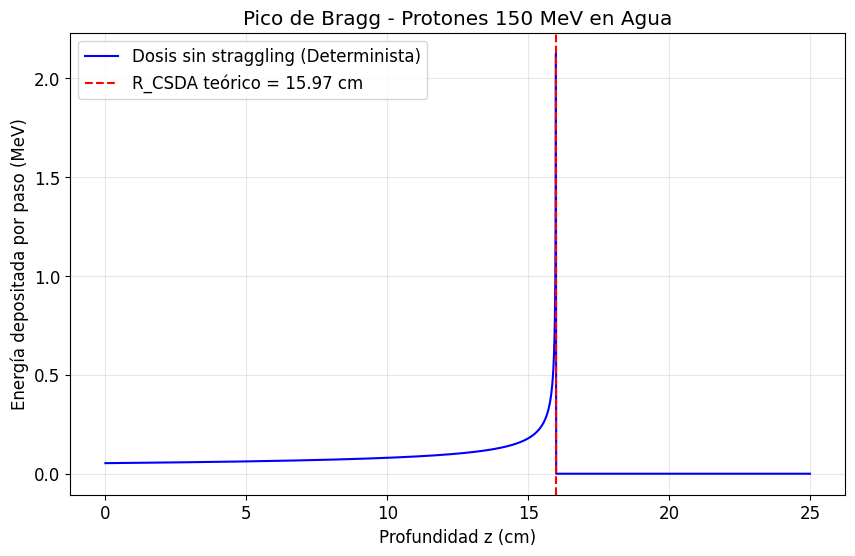

In [4]:
N = 10000
E0 = 150.0 # MeV
dx = 0.01 # cm (0.1 mm)
max_steps = 2500 # Suficiente para cubrir ~25 cm
z_bins = np.arange(0, max_steps * dx, dx)

# Array para acumular la dosis (energía depositada) en función de la profundidad z
dosis_determinista = np.zeros(max_steps)

# Inicializamos las energías de los N protones
E_actual = np.full(N, E0)
activos = np.ones(N, dtype=bool) # Máscara para saber qué protones siguen en movimiento

for step in range(max_steps):
    # Solo procesamos los protones que siguen teniendo energía
    protones_activos = E_actual[activos]
    
    if len(protones_activos) == 0:
        break
        
    # Calculamos dE/dx para cada protón activo (vectorizado usando numpy)
    dE_dx = np.array([bethe_bloch(e) for e in protones_activos])
    dE = dE_dx * dx
    
    # Restamos la energía y evitamos energías negativas
    E_actual[activos] -= dE
    E_actual[E_actual < 0] = 0
    
    # Acumulamos la energía depositada en este paso de profundidad
    dosis_determinista[step] = np.sum(dE)
    
    # Actualizamos la máscara de protones activos
    activos = E_actual > 0

# Normalización de la dosis por partícula
dosis_determinista /= N

# Gráfico
plt.plot(z_bins, dosis_determinista, label='Dosis sin straggling (Determinista)', color='blue')
R_csda_150 = rango_csda(E0)
plt.axvline(R_csda_150, color='red', linestyle='--', label=f'R_CSDA teórico = {R_csda_150:.2f} cm')
plt.xlabel('Profundidad z (cm)')
plt.ylabel('Energía depositada por paso (MeV)')
plt.title('Pico de Bragg - Protones 150 MeV en Agua')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## d) Incorporación del Energy Straggling

La aproximación gaussiana de Bohr nos dice que la pérdida de energía fluctúa estadísticamente. La varianza se puede escribir reordenando las constantes de Bethe-Bloch como:

$$\sigma_{E}^{2} = K \rho \frac{Z}{A} m_e c^2 \frac{z^2}{\beta^2} \Delta x$$

Al agregar esta fluctuación $\Delta E \sim \mathcal{N}(\langle\Delta E\rangle, \sigma_E^2)$, observaremos un ensanchamiento espacial del Pico de Bragg ($\sigma_R$). 

**Relevancia Clínica:** Este ensanchamiento físico es crítico en radiobiología. Aunque el pico de Bragg permite concentrar el daño celular (como en modelos de gliomas), el *straggling* estocástico hace que el borde distal del haz de radiación no sea un corte perfectamente abrupto. Clínicamente, esto se traduce en un margen de incerteza (penumbra distal) que debe considerarse al planificar el tratamiento para asegurar que todo el volumen tumoral reciba una dosis letal sin quemar órganos sanos adyacentes.

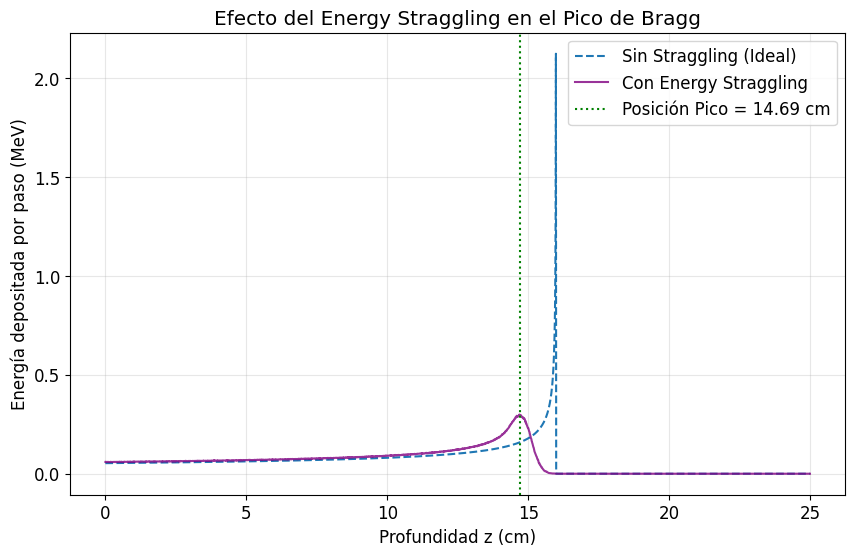

Posición del pico con straggling: 14.69 cm
Ensanchamiento estimado del pico (sigma_R): 0.7389 cm


In [5]:
dosis_straggling = np.zeros(max_steps)
E_actual_strag = np.full(N, E0)
activos_strag = np.ones(N, dtype=bool)

# Constante para la varianza de Bohr
C_bohr = K * rho * Z_A * m_e_c2 * (z**2) * dx

for step in range(max_steps):
    protones_activos = E_actual_strag[activos_strag]
    
    if len(protones_activos) == 0:
        break
        
    gamma = 1.0 + (protones_activos / M_p)
    beta2 = 1.0 - (1.0 / gamma**2)
    
    # Energía promedio esperada
    dE_promedio = np.array([bethe_bloch(e) for e in protones_activos]) * dx
    
    # Varianza de Bohr
    sigma_E2 = C_bohr / beta2
    sigma_E = np.sqrt(sigma_E2)
    
    # Aplicar fluctuación estadística
    dE_fluctuado = np.random.normal(loc=dE_promedio, scale=sigma_E)
    
    # Limitar pérdidas físicas (no puede ganar energía ni perder más de la que tiene)
    dE_fluctuado = np.clip(dE_fluctuado, 0, protones_activos)
    
    E_actual_strag[activos_strag] -= dE_fluctuado
    dosis_straggling[step] = np.sum(dE_fluctuado)
    activos_strag = E_actual_strag > 0

dosis_straggling /= N

# Cálculo del ensanchamiento del pico sigma_R
# Aproximamos sigma_R analizando la distribución espacial cerca del pico
z_pico = z_bins[np.argmax(dosis_straggling)]
pico_max = np.max(dosis_straggling)

# Ancho a media altura (FWHM) para estimar sigma_R
mitad_dosis = pico_max / 2.0
indices_sobre_mitad = np.where(dosis_straggling >= mitad_dosis)[0]
z_min_fwhm = z_bins[indices_sobre_mitad[0]]
z_max_fwhm = z_bins[indices_sobre_mitad[-1]]
FWHM = z_max_fwhm - z_min_fwhm
sigma_R = FWHM / 2.355  # Relación para una gaussiana

# Gráfico comparativo
plt.plot(z_bins, dosis_determinista, label='Sin Straggling (Ideal)', linestyle='--')
plt.plot(z_bins, dosis_straggling, label='Con Energy Straggling', color='purple', alpha=0.8)
plt.axvline(z_pico, color='green', linestyle=':', label=f'Posición Pico = {z_pico:.2f} cm')

plt.xlabel('Profundidad z (cm)')
plt.ylabel('Energía depositada por paso (MeV)')
plt.title('Efecto del Energy Straggling en el Pico de Bragg')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Posición del pico con straggling: {z_pico:.2f} cm")
print(f"Ensanchamiento estimado del pico (sigma_R): {sigma_R:.4f} cm")